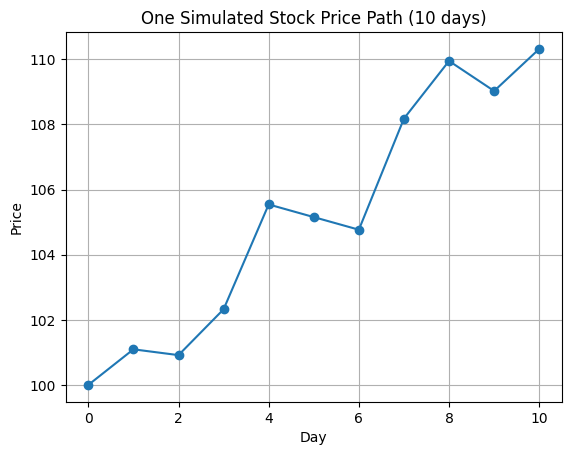

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100                 # initial stock price
mu = 0.001               # mean daily return
sigma = 0.02            # daily volatility
days = 10               # number of days
np.random.seed(42)      # for reproducibility

# Generate random daily returns
returns = np.random.normal(loc=mu, scale=sigma, size=days)

# Compute price path
prices = [S0]
for r in returns:
    next_price = prices[-1] * (1 + r)
    prices.append(next_price)

# Plot the path
plt.plot(prices, marker='o')
plt.title("One Simulated Stock Price Path (10 days)")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid(True)
plt.show()


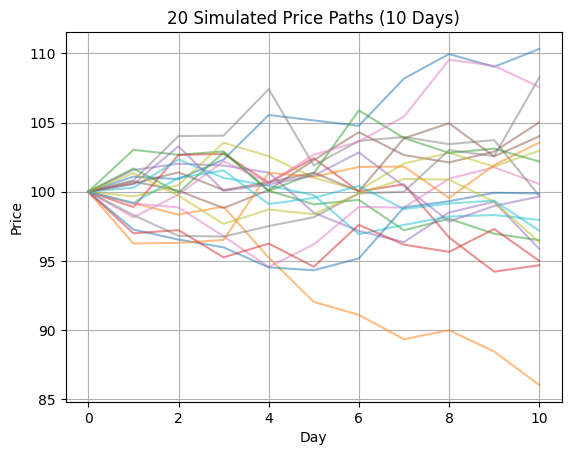

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100
mu = 0.001
sigma = 0.02
days = 10
n_simulations = 1000
np.random.seed(42)

# Simulate 1000 paths
returns = np.random.normal(loc=mu, scale=sigma, size=(n_simulations, days))
price_paths = np.zeros((n_simulations, days + 1))
price_paths[:, 0] = S0

# Fill in price paths
for t in range(1, days + 1):
    price_paths[:, t] = price_paths[:, t - 1] * (1 + returns[:, t - 1])

# Plot some paths
plt.plot(price_paths[:20].T, alpha=0.5)
plt.title("20 Simulated Price Paths (10 Days)")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid(True)
plt.show()


In [4]:
# Analyze final prices
final_prices = price_paths[:, -1]
expected_price = np.mean(final_prices)
var_95 = np.percentile(final_prices, 5)

print(f"Expected Price after 10 days: {expected_price:.2f}")
print(f"5% Value at Risk (VaR): {S0 - var_95:.2f}")

Expected Price after 10 days: 100.96
5% Value at Risk (VaR): 9.26


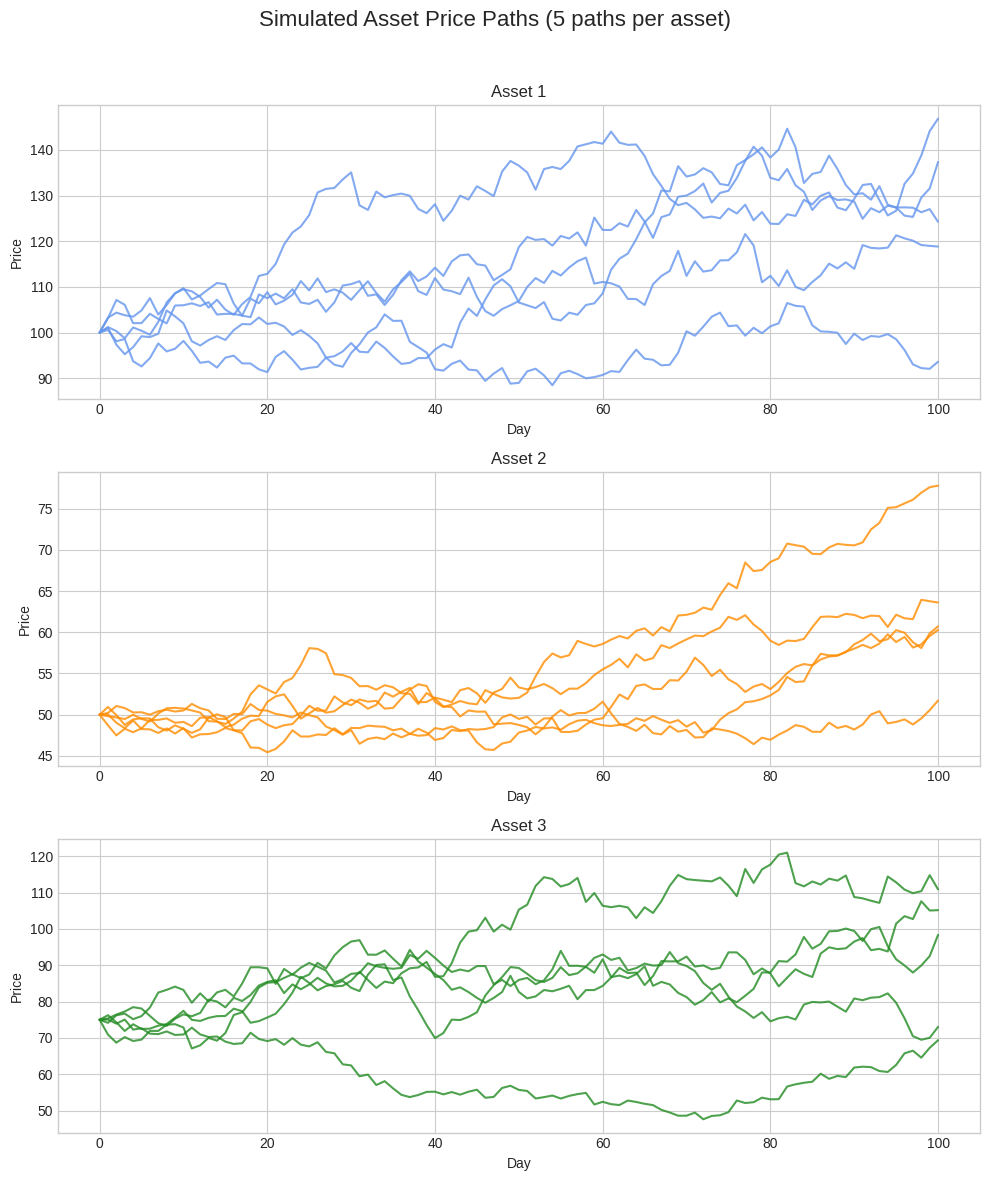

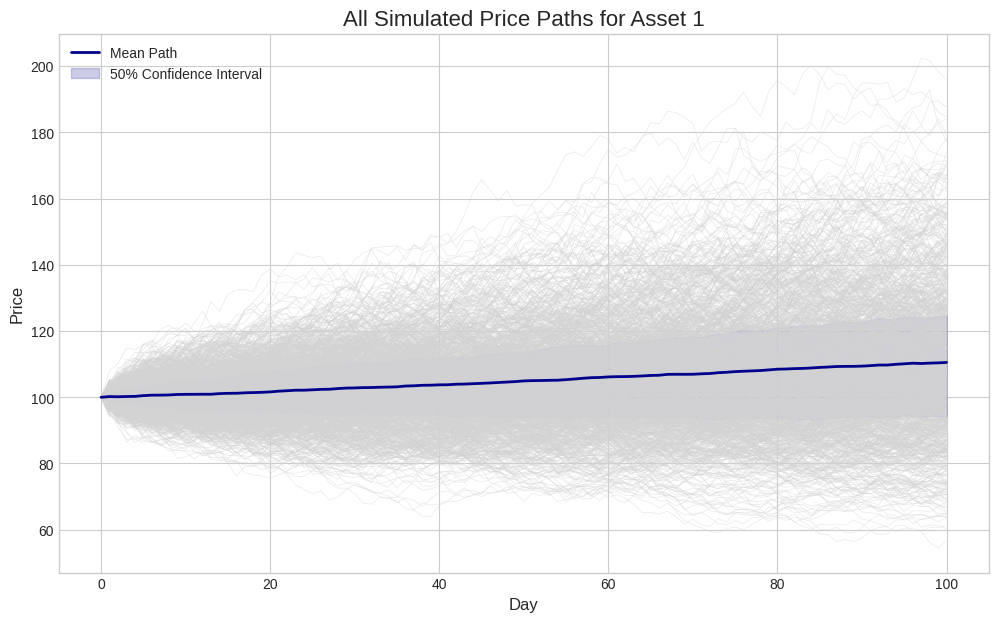

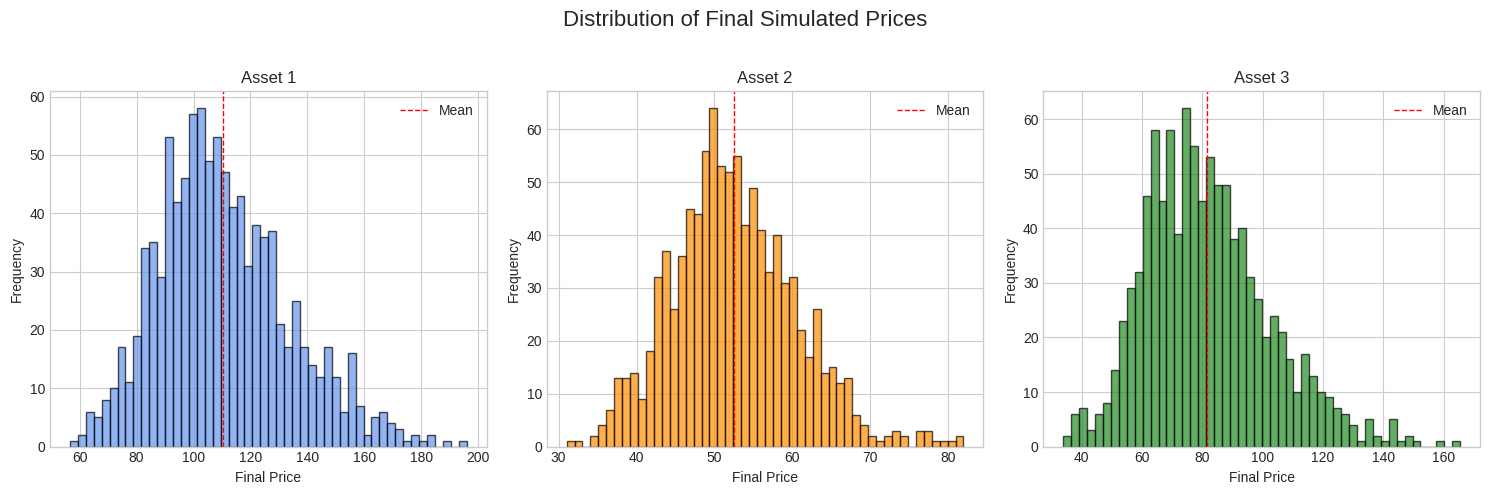

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Settings ---
n_assets = 3
n_days = 100  # Increased days for a more interesting visualization
n_simulations = 1000
S0 = np.array([100, 50, 75])
mu = np.array([0.001, 0.0005, 0.0008])
sigma = np.array([0.02, 0.015, 0.025])

# Correlation matrix (must be symmetric and positive semi-definite)
corr_matrix = np.array([
    [1.0, 0.3, 0.2],
    [0.3, 1.0, 0.4],
    [0.2, 0.4, 1.0]
])

# Convert to covariance matrix
cov_matrix = np.outer(sigma, sigma) * corr_matrix

# Cholesky decomposition
L = np.linalg.cholesky(cov_matrix)

# --- Generate Simulations ---
price_paths = np.zeros((n_simulations, n_assets, n_days + 1))
price_paths[:, :, 0] = S0

np.random.seed(42)
for t in range(1, n_days + 1):
    Z = np.random.normal(size=(n_simulations, n_assets))
    correlated_returns = Z @ L.T + mu
    price_paths[:, :, t] = price_paths[:, :, t - 1] * (1 + correlated_returns)

# --- Visualization Improvements ---

# 1. Individual Subplots for Each Asset
#    - Clearer separation of each asset's paths.
#    - Use different colors for clarity.
#    - Improved titles and labels.

plt.style.use('seaborn-v0_8-whitegrid') # A clean, modern style
fig, axes = plt.subplots(n_assets, 1, figsize=(10, 12))
fig.suptitle("Simulated Asset Price Paths (5 paths per asset)", fontsize=16)

colors = ['cornflowerblue', 'darkorange', 'forestgreen']

for i in range(n_assets):
    ax = axes[i]
    ax.plot(price_paths[:5, i, :].T, color=colors[i], alpha=0.8)
    ax.set_title(f"Asset {i+1}", fontsize=12)
    ax.set_xlabel("Day")
    ax.set_ylabel("Price")
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
plt.show()


# 2. Single Asset with all simulations and a Confidence Interval
#    - Focus on a single asset to show the full range of outcomes.
#    - Shaded area highlights the central tendency of the simulations.

plt.figure(figsize=(12, 7))
asset_index = 0  # Focus on the first asset

# Plot all simulation paths for the chosen asset
plt.plot(price_paths[:, asset_index, :].T, color='lightgray', alpha=0.5, linewidth=0.5)

# Calculate and plot the mean path
mean_path = np.mean(price_paths[:, asset_index, :], axis=0)
plt.plot(mean_path, color='darkblue', linewidth=2, label='Mean Path')

# Calculate and plot a 50% confidence interval (25th to 75th percentile)
percentile_25 = np.percentile(price_paths[:, asset_index, :], 25, axis=0)
percentile_75 = np.percentile(price_paths[:, asset_index, :], 75, axis=0)
plt.fill_between(range(n_days + 1), percentile_25, percentile_75, color='darkblue', alpha=0.2, label='50% Confidence Interval')

plt.title(f"All Simulated Price Paths for Asset {asset_index+1}", fontsize=16)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


# 3. Distribution of Final Prices (Histograms)
#    - Provides a statistical summary of the simulation's end state.
#    - Shows the probability distribution of final prices for each asset.

fig, axes = plt.subplots(1, n_assets, figsize=(15, 5))
fig.suptitle("Distribution of Final Simulated Prices", fontsize=16)

for i in range(n_assets):
    ax = axes[i]
    final_prices = price_paths[:, i, -1] # Get the prices at the last day
    ax.hist(final_prices, bins=50, color=colors[i], alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(final_prices), color='red', linestyle='dashed', linewidth=1, label='Mean')
    ax.set_title(f"Asset {i+1}", fontsize=12)
    ax.set_xlabel("Final Price")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()